Stripe verification
-------------------
This notebook is used to verify if the stripe and its subcomponents are functioning correctly. As a reference the Excel from Chalmers is used which calculates the link budget for a signal travelling over the stripe.

An CP-OFDM signal is transmitted from the CU with the following stripe settings:
 - PA noise figure: 10 dB
 - PA mode: linear
 - Fiber length: 1 m
 - Fiber de-embedding: 3 dB
 - Transmit power: -8 dBm
 - Pilot mode: block
 - Oversampling factor: 4

This simulation must match the following link budget otherwise a bug slipped into the simulator:

| Name            | Power level | Noise level | Distance | S/N | OIP3 | PIM3 | S/(N+IMD) | S/IMD | DC power |
|-----------------|-------------|-------------|----------|-----|------|------|-----------|-------|----------|
| Central station | -8          | -100        | 0        |     | 20   | -64  | 56        | 56    | 0.34     |
| Node 1 in       | -19         | -69         | 1        | 50  | 9    | -75  | 49        | 56    |          |
| Node 1 out      | -8          | -58         | 1        | 50  | 17   | -58  | 47        | 50    | 0.34     |
| Node 2 in       | -19         | -66         | 2        | 47  | 6    | -69  | 45        | 50    |          |
| Node 2 out      | -8          | -55         | 2        | 47  | 15   | -54  | 44        | 46    | 0.34     |
| Node 2 in       | -19         | -64         | 3        | 45  | 4    | -65  | 43        | 46    |          |
| Node 2 out      | -8          | -53         | 3        | 45  | 14   | -52  | 42        | 44    | 0.34     |
| Node 2 in       | -19         | -63         | 4        | 44  | 3    | -63  | 41        | 44    |          |
| Node 2 out      | -8          | -52         | 4        | 44  | 13   | -50  | 40        | 42    | 0.34     |
| Node 2 in       | -19         | -62         | 5        | 43  | 2    | -61  | 40        | 42    |          |
| Node 2 out      | -8          | -51         | 5        | 43  | 12   | -48  | 39        | 40    | 0.34     |
| Node 2 in       | -19         | -61         | 6        | 42  | 1    | -59  | 38        | 40    |          |
| Node 2 out      | -8          | -50         | 6        | 42  | 12   | -47  | 37        | 39    | 0.34     |
| Node 2 in       | -19         | -61         | 7        | 42  | 1    | -58  | 37        | 39    |          |
| Node 2 out      | -8          | -50         | 7        | 42  | 11   | -46  | 36        | 38    | 0.34     |
| Node 2 in       | -19         | -60         | 8        | 41  | 0    | -57  | 36        | 38    |          |
| Node 2 out      | -8          | -49         | 8        | 41  | 10   | -45  | 36        | 37    | 0.34     |
| Node 2 in       | -19         | -60         | 9        | 41  | -1   | -56  | 35        | 37    |          |
| Node 2 out      | -8          | -49         | 9        | 41  | 10   | -44  | 35        | 36    | 0.34     |
| Node 2 in       | -19         | -59         | 10       | 40  | -1   | -55  | 35        | 36    |          |
| Node 2 out      | -8          | -48         | 10       | 40  | 10   | -43  | 34        | 35    | 0.34     |
| Node 2 in       | -19         | -59         | 11       | 40  | -1   | -54  | 34        | 35    |          |
| Node 2 out      | -8          | -48         | 11       | 40  | 9    | -42  | 33        | 34    | 0.34     |
| Node 2 in       | -19         | -58         | 12       | 39  | -2   | -53  | 33        | 34    |          |
| Node 2 out      | -8          | -47         | 12       | 39  | 9    | -42  | 33        | 34    | 0.34     |
| Node 2 in       | -19         | -58         | 13       | 39  | -2   | -53  | 33        | 34    |          |
| Node 2 out      | -8          | -47         | 13       | 39  | 9    | -41  | 32        | 33    | 0.34     |
| Node 2 in       | -19         | -58         | 14       | 39  | -2   | -52  | 32        | 33    |          |
| Node 2 out      | -8          | -47         | 14       | 39  | 8    | -40  | 32        | 32    | 0.34     |
| Node 2 in       | -19         | -57         | 15       | 38  | -3   | -51  | 32        | 32    |          |
| Node 2 out      | -8          | -46         | 15       | 38  | 8    | -40  | 31        | 32    | 0.34     |
| Node 2 in       | -19         | -57         | 16       | 38  | -3   | -51  | 31        | 32    |          |
| Node 2 out      | -8          | -46         | 16       | 38  | 8    | -39  | 31        | 31    | 0.34     |
| Node 2 in       | -19         | -57         | 17       | 38  | -3   | -50  | 31        | 31    |          |
| Node 2 out      | -8          | -46         | 17       | 38  | 7    | -39  | 30        | 31    | 0.34     |
| Node 2 in       | -19         | -57         | 18       | 38  | -4   | -50  | 30        | 31    |          |
| Node 2 out      | -8          | -46         | 18       | 38  | 7    | -38  | 30        | 30    | 0.34     |
| Node 2 in       | -19         | -56         | 19       | 37  | -4   | -49  | 30        | 30    |          |
| Node 2 out      | -8          | -45         | 19       | 37  | 7    | -38  | 29        | 30    | 0.34     |


In [1]:
import yaml
import numpy as np

from plotter import plotter
from sub_THz_stripe.radiostripe.radiostripe import RadioStripe
from sub_THz_stripe.central_unit.central_unit import CentralUnit
from wireless_channel.waveforms import Waveform
from sub_THz_stripe.utils import calculate_nmse

In [2]:
environment = "office_space_inline"

# Read out the config file.
config_file = f"environments/{environment}/config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

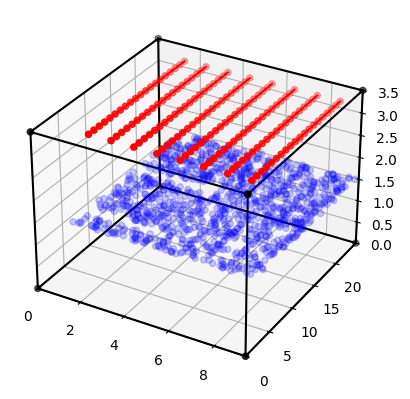

In [3]:
# Plot the room with the strip in it.
plotter.plot_room(config)

In [4]:
# Read out the Waveform config file.
config_file = "environments/waveform_config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    waveform_config = yaml.safe_load(file)

# Construct the waveform class based on the loaded configuration.
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

ue_pos = None
for ue in config["ue_positions"]:
    if ue["x"] == 2.0 and ue["y"] == 21.5 and ue["z"] == 1.5:
        ue_pos = ue
        break

In [5]:
# Read out the Component config file.
config_file = "environments/component_config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    component_config = yaml.safe_load(file)

# Build all the RadioStripe objects based on the configuration.
stripes: list[RadioStripe] = []
for stripe_cfg in config["radio_stripes"]:
    stripes.append(RadioStripe.from_config_locations(stripe_cfg, component_config, config["antenna"]["N_antennas"], wf))

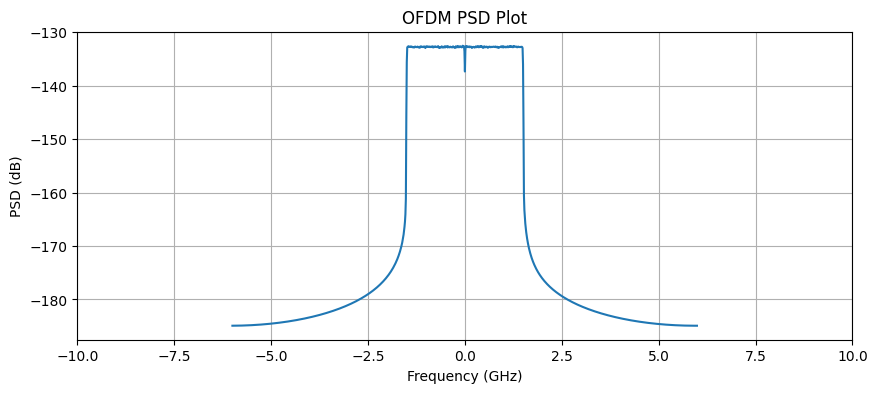

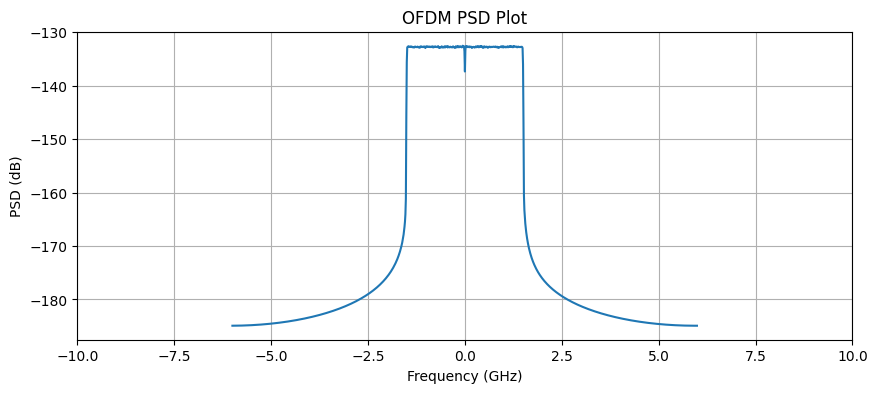

In [6]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)
wf.plot_psd()

In [7]:

cu = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_cu = cu.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

In [8]:
def calculate_papr(data, percentile: float = 99.5):
    """Calculate the PAPR of and OFDM signal.

    Arguments
    ---------
        data np.ndarray
            The input data for which to calculate the PAPR.
        percentile float
            For which percentile to calculate the PAPR.
    
    Returns
    -------
        The PAPR in dB.
    """
    abs_data = np.abs(data)
    threshold = np.percentile(abs_data, percentile)
    sdata = abs_data[abs_data < threshold]

    papr = np.max(sdata ** 2) / np.mean(abs_data ** 2)

    return 10 * np.log10(papr)

print(f"PAPR 99.5th percintile: {calculate_papr(ofdm_time)} dB")

power = np.abs(ofdm_time)**2
papr = 10 * np.log10(np.max(power) / np.mean(power))
print(f'worse case PAPR max/mean: {papr}')

PAPR 99.5th percintile: 7.259078737640351 dB
worse case PAPR max/mean: 10.358560399423995


7.259078737640351
7.208991179149611
Stripe: 0
RU 0: 4.043054879260038
RU 1: 4.043410714703803
RU 2: 4.045680827597743
RU 3: 4.047053503270528
RU 4: 4.04937220195005
RU 5: 4.048395015347188
RU 6: 4.050672531172801
RU 7: 4.052322866339765
RU 8: 4.051308981094393
RU 9: 4.054523136047943
RU 10: 4.055643248001826
RU 11: 4.056943349342392
RU 12: 4.05839912624377
RU 13: 4.059766739021605
RU 14: 4.060869968216073
RU 15: 4.062961073619255
RU 16: 4.064017778387681
RU 17: 4.064782138765297
RU 18: 4.066839038481284
RU 19: 1.0
Stripe: 1
RU 0: 1.0
RU 1: 1.0
RU 2: 1.0
RU 3: 1.0
RU 4: 1.0
RU 5: 1.0
RU 6: 1.0
RU 7: 1.0
RU 8: 1.0
RU 9: 1.0
RU 10: 1.0
RU 11: 1.0
RU 12: 1.0
RU 13: 1.0
RU 14: 1.0
RU 15: 1.0
RU 16: 1.0
RU 17: 1.0
RU 18: 1.0
RU 19: 1.0
Stripe: 2
RU 0: 1.0
RU 1: 1.0
RU 2: 1.0
RU 3: 1.0
RU 4: 1.0
RU 5: 1.0
RU 6: 1.0
RU 7: 1.0
RU 8: 1.0
RU 9: 1.0
RU 10: 1.0
RU 11: 1.0
RU 12: 1.0
RU 13: 1.0
RU 14: 1.0
RU 15: 1.0
RU 16: 1.0
RU 17: 1.0
RU 18: 1.0
RU 19: 1.0
Stripe: 3
RU 0: 1.0
RU 1: 1.0
RU 2: 1.0


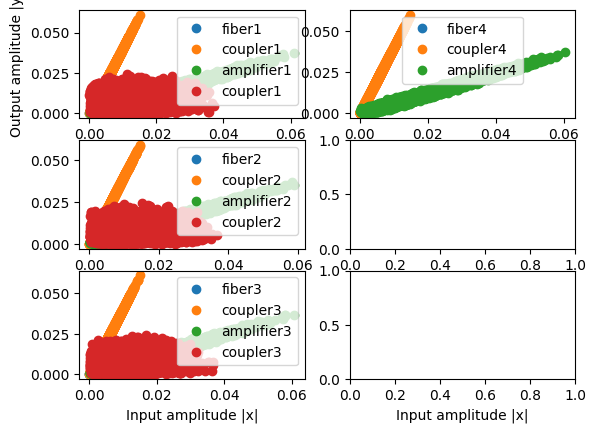

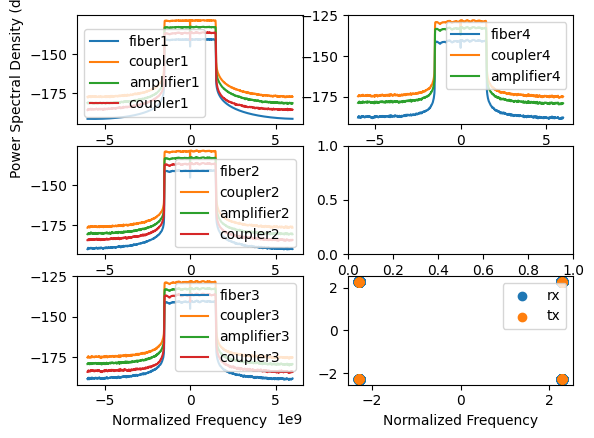

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage0: -8.0 dBm
Psig stage0: -7.999999999999999 dBm
Pnoise stage0: -58.51764119324863 dBm
NMSE stage0: -50.52088559275988 dB


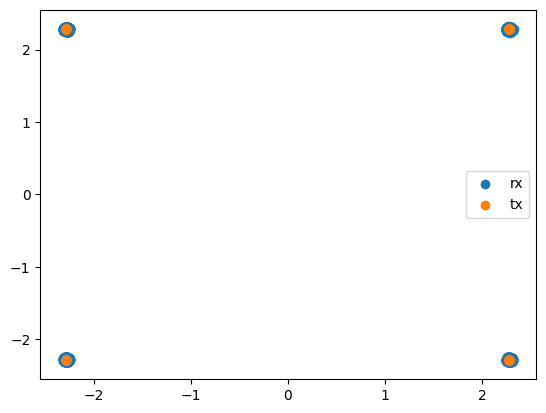

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage1: -8.0508499980341 dBm
Psig stage1: -7.999999999999999 dBm
Pnoise stage1: -55.49375184999984 dBm
NMSE stage1: -47.497037498213615 dB


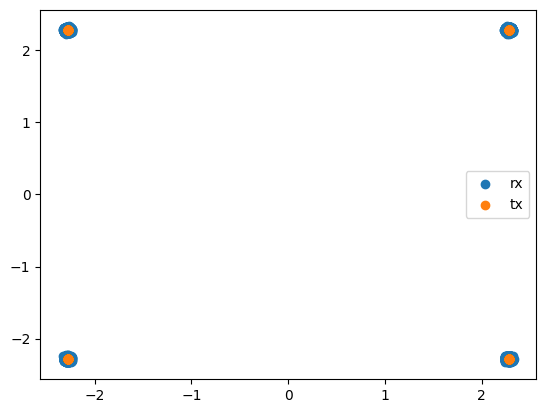

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage2: -8.096739373435874 dBm
Psig stage2: -7.999999999999999 dBm
Pnoise stage2: -53.71736237509867 dBm
NMSE stage2: -45.720155212653815 dB


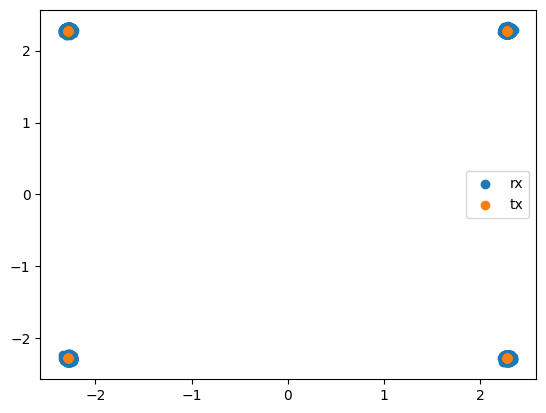

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage3: -8.135912937723809 dBm
Psig stage3: -7.999999999999999 dBm
Pnoise stage3: -52.41689372053274 dBm
NMSE stage3: -44.41960568072035 dB


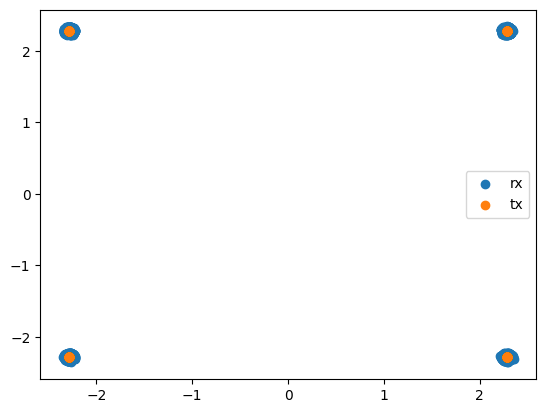

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage4: -8.169955532741826 dBm
Psig stage4: -7.999999999999999 dBm
Pnoise stage4: -51.401562127178416 dBm
NMSE stage4: -43.40428070338778 dB


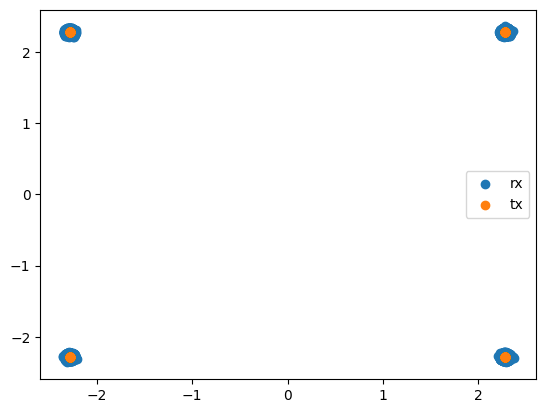

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage5: -8.194634912811614 dBm
Psig stage5: -7.999999999999999 dBm
Pnoise stage5: -50.59985988777149 dBm
NMSE stage5: -42.60011511056617 dB


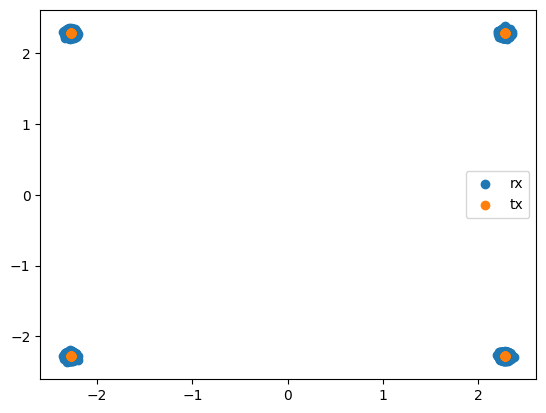

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage6: -8.218762273412967 dBm
Psig stage6: -7.999999999999999 dBm
Pnoise stage6: -49.89938712305124 dBm
NMSE stage6: -41.90201108596841 dB


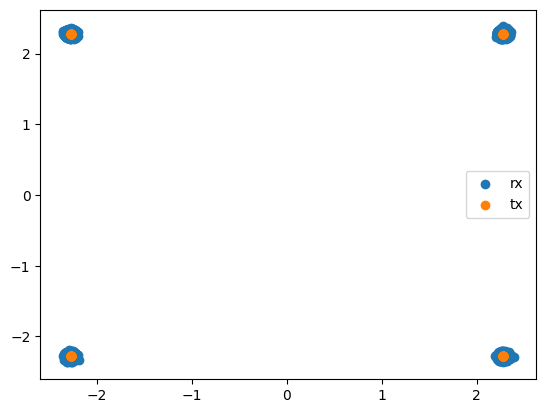

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage7: -8.235324754048229 dBm
Psig stage7: -7.999999999999999 dBm
Pnoise stage7: -49.30755523764101 dBm
NMSE stage7: -41.31229237111732 dB


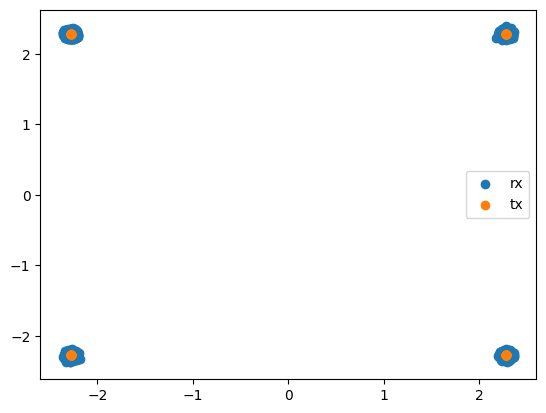

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage8: -8.245110701314207 dBm
Psig stage8: -7.999999999999999 dBm
Pnoise stage8: -48.807987774636146 dBm
NMSE stage8: -40.814114650772495 dB


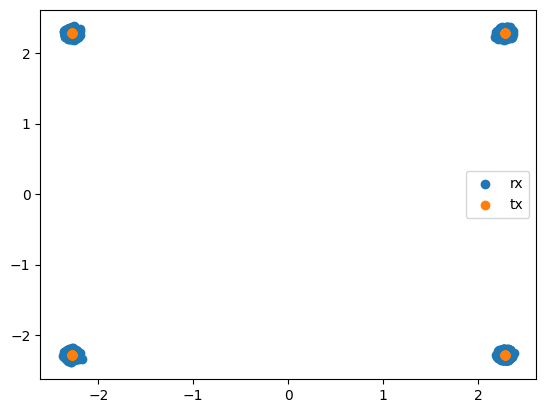

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage9: -8.25434262458225 dBm
Psig stage9: -7.999999999999999 dBm
Pnoise stage9: -48.298993941714514 dBm
NMSE stage9: -40.306197986518356 dB


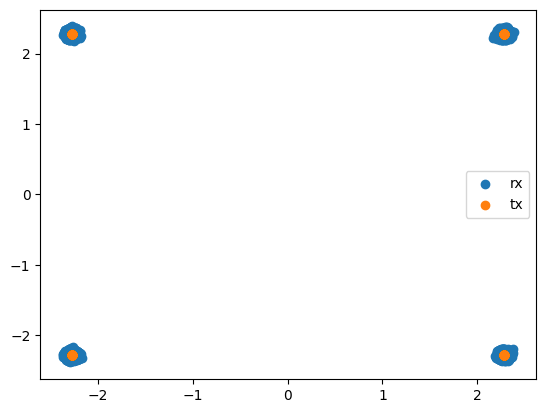

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage10: -8.254130754783262 dBm
Psig stage10: -7.999999999999999 dBm
Pnoise stage10: -47.82991878783639 dBm
NMSE stage10: -39.838468048549196 dB


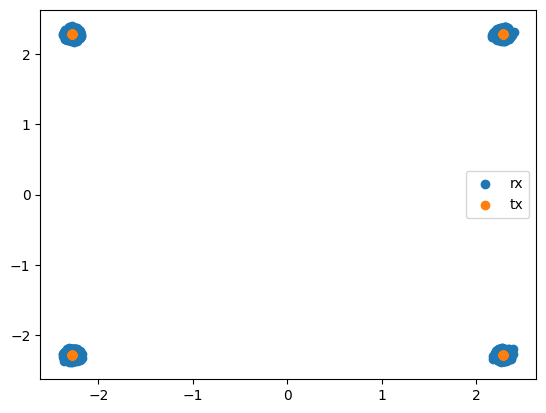

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage11: -8.244817345678847 dBm
Psig stage11: -7.999999999999999 dBm
Pnoise stage11: -47.423783422230265 dBm
NMSE stage11: -39.43084718365139 dB


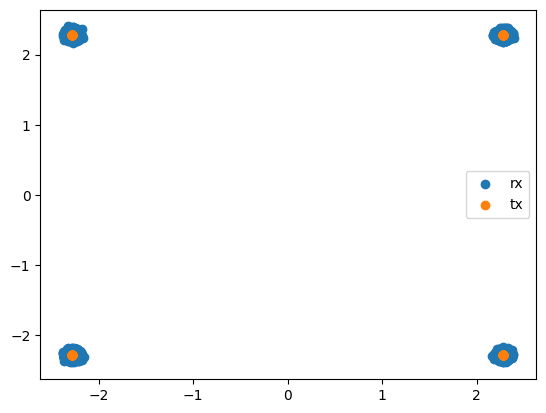

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage12: -8.234793544804374 dBm
Psig stage12: -7.999999999999999 dBm
Pnoise stage12: -47.04828902163722 dBm
NMSE stage12: -39.05333090962456 dB


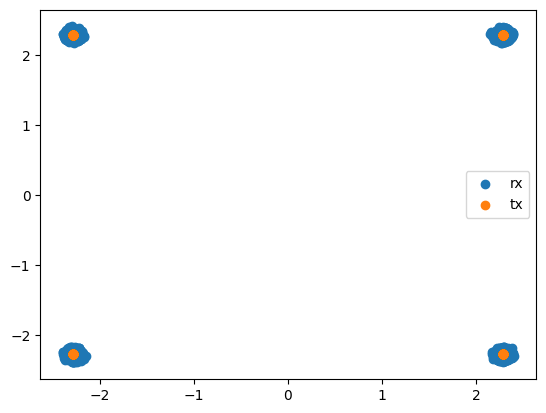

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage13: -8.218369319410698 dBm
Psig stage13: -7.999999999999999 dBm
Pnoise stage13: -46.68486126373507 dBm
NMSE stage13: -38.68799200244159 dB


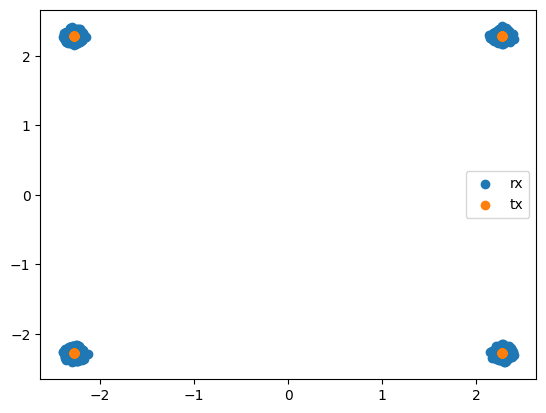

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage14: -8.193956807101424 dBm
Psig stage14: -7.999999999999999 dBm
Pnoise stage14: -46.32864558349159 dBm
NMSE stage14: -38.33043972236286 dB


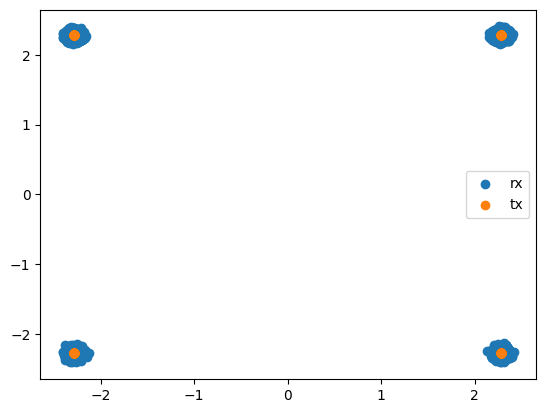

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage15: -8.169087541869523 dBm
Psig stage15: -7.999999999999999 dBm
Pnoise stage15: -46.032637429444954 dBm
NMSE stage15: -38.0342036067197 dB


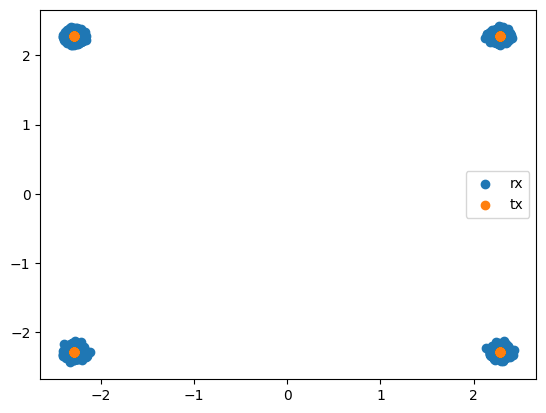

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage16: -8.13501432802764 dBm
Psig stage16: -7.999999999999999 dBm
Pnoise stage16: -45.73758770947151 dBm
NMSE stage16: -37.73825664681482 dB


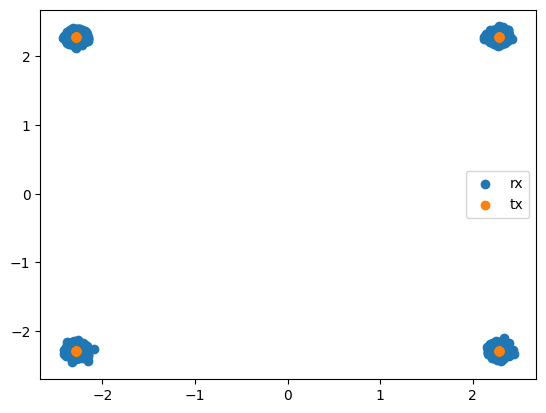

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage17: -8.095652187263116 dBm
Psig stage17: -7.999999999999999 dBm
Pnoise stage17: -45.473007356461665 dBm
NMSE stage17: -37.47656674271766 dB


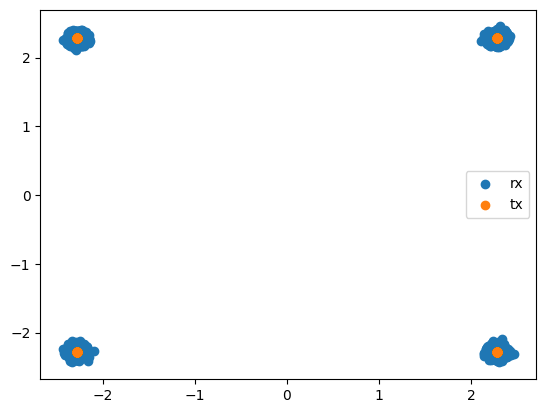

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage18: -8.049636749163584 dBm
Psig stage18: -7.999999999999999 dBm
Pnoise stage18: -45.217831791451474 dBm
NMSE stage18: -37.221218396195816 dB


In [9]:
ru_shift = [0, 0, 0, 0]
stripes[0].active_unit = 19
print(calculate_papr(ofdm_time_after_cu))
y, imdata = stripes[0].transmit(ofdm_time_after_cu, ru_shift)
print(calculate_papr(imdata[3]))

fig, fig2 = plotter.plot_im_data_tx(imdata[1:(4*4)+1], wf)

for idx, stripe in enumerate(stripes):
    print(f"Stripe: {idx}")
    for jdx, ru in enumerate(stripe.radio_units):
        print(f"RU {jdx}: {ru.boost_amp.gain}")

for i, (sig_in, y) in enumerate(zip(imdata[0:-5:4], imdata[4:-5:4])):
    nmse, pnoise, psig = calculate_nmse(imdata[0], y, wf)
    print(f"Psig_in stage{i}: {10 * np.log10(np.mean(np.abs(sig_in ** 2) * 1000))} dBm")
    print(f"Psig stage{i}: {psig} dBm")
    print(f"Pnoise stage{i}: {pnoise} dBm")
    print(f"NMSE stage{i}: {nmse} dB")

NMSE: -37.221218396195816
BER: 0.0


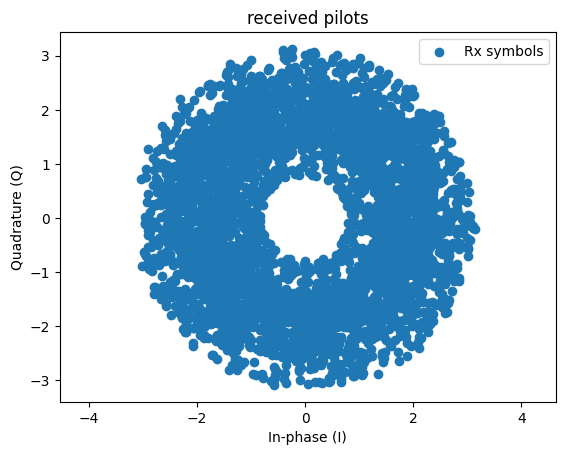

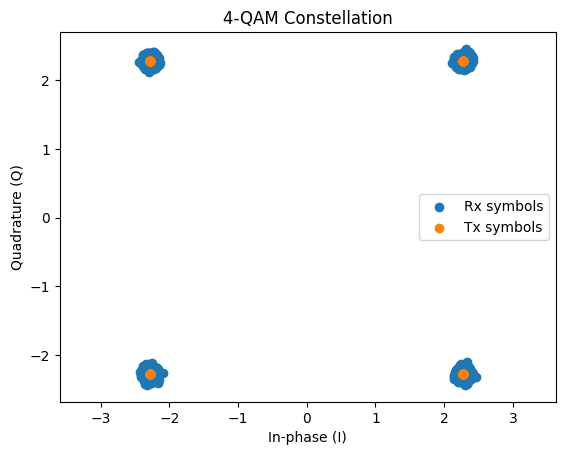

In [10]:
y_combined_freq = wf.ofdm_time_to_freq(imdata[-5])
x_combined_freq = wf.ofdm_time_to_freq(ofdm_time)
xsubc = wf.extract_subcarriers(x_combined_freq)

# sanity check
rx_subc = wf.extract_subcarriers(y_combined_freq)
# look at a few carriers around pilots and data
wf.plot_constellation(rx_subc[0, wf.pilot_indices], title="received pilots")

# channel estimation
subc = wf.extract_subcarriers(y_combined_freq)
H_est = wf.channel_estimate_ls(subc)

# equalization
eq_subc = wf.equalize_one_tap(subc, H_est)

nmse = np.sum(np.abs(eq_subc - xsubc) ** 2) / np.sum(np.abs(xsubc) ** 2)

# Demap data carriers and rebuild stream
data_symbols = wf.demap_data_from_grid(eq_subc).flatten()  # these are the received QAM symbols

y_qam = data_symbols

# quick sanity
assert y_qam.shape[0] == qam.shape[0], f"Lengths differ: rx {y_qam.shape[0]} tx {qam.shape[0]}"

wf.plot_constellation(eq_subc, symbols_tx=xsubc)

y_bits = wf.qam_to_bits(y_qam)

ber = wf.compute_ber(bits, y_bits)
print(f"NMSE: {10 * np.log10(nmse)}")
print(f"BER: {ber}")

In [11]:
import matplotlib.pyplot as plt

rx_subc shape: (10, 4096)
xsubc shape: (10, 4096)
xsubc: [-2.28013447-2.28013447j -2.28013447+2.28013447j -2.28013447+2.28013447j
  2.28013447-2.28013447j  2.28013447-2.28013447j -2.28013447-2.28013447j
 -2.28013447+2.28013447j  2.28013447-2.28013447j -2.28013447-2.28013447j
  2.28013447-2.28013447j  2.28013447+2.28013447j  2.28013447+2.28013447j
  2.28013447-2.28013447j -2.28013447-2.28013447j  2.28013447-2.28013447j
  2.28013447-2.28013447j  2.28013447+2.28013447j -2.28013447+2.28013447j
  2.28013447-2.28013447j -2.28013447-2.28013447j]


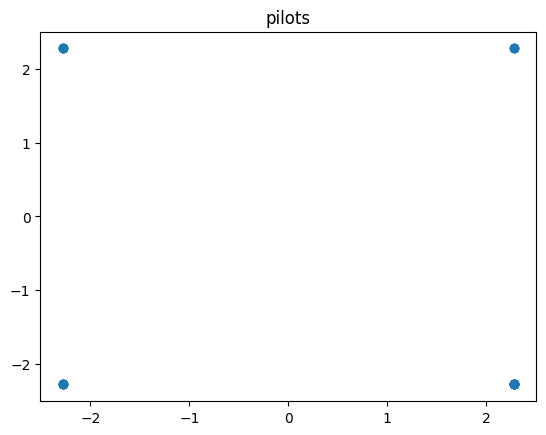

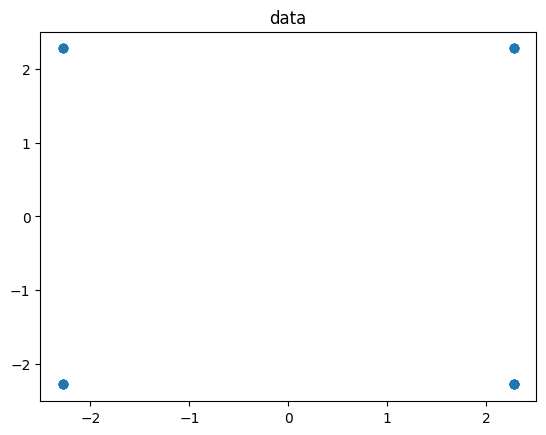

In [12]:
print(f'rx_subc shape: {rx_subc.shape}')
x_combined_freq = wf.ofdm_time_to_freq(ofdm_time)
xsubc = wf.extract_subcarriers(x_combined_freq)
print(f'xsubc shape: {xsubc.shape}')
symbolidx = 0
nr_symbols_to_print = 20
print(f'xsubc: {xsubc[symbolidx, :nr_symbols_to_print]}')

plt.title('pilots')
plt.scatter(xsubc[symbolidx,:nr_symbols_to_print].real, xsubc[symbolidx,:nr_symbols_to_print].imag)
plt.show()

plt.title('data')
symbolidx = 1
plt.scatter(xsubc[symbolidx,:nr_symbols_to_print].real, xsubc[symbolidx,:nr_symbols_to_print].imag)
plt.show()
